# Supplementary analysis S5.3: session, trial order, and recreation accuracy

Runs the supplementary control analyses reported in Supplementary Section S5.3
(Tables S5.2 and S5.3, Figures S5.4 and S5.5).

**Why this is needed.** Trials were pseudo-randomised per data collection session, and every
participant within a session received the same order. That leaves two nuisance sources of
variance unmodelled by the main analyses: position in the trial sequence (fatigue, practice,
drift in drawing style) and membership of a particular session (room, time of day, experimenter,
group composition, and the specific order that session drew).

**Three analyses, in order.**

1. **Experimental trials** — does trial position shift the *content* of the recreations, over and
   above stroboscopic frequency? There is no ground truth for a hallucination, so the question can
   only be asked of the feature values themselves.
2. **Validation trials** — the same question, with the stimulus image's own feature value as a
   covariate (participants were randomly assigned a different image within each category, so this
   covariate is what makes the trial-order term interpretable).
3. **Recreation accuracy** — the question the validation data can answer that the experimental data
   cannot: does participants' *error* relative to the target image grow across the session?
   This is the substantively meaningful version of the trial-order question, and it feeds directly
   into the validation claim in Section 5.2.2.4.

All models share the random structure `(1 | session) + (1 | participant within session)`, since
each participant attended exactly one session.

Run the cells in order; roughly two minutes in total. No packages beyond those already used in
`035_feature_experimetnal_analysis.ipynb` are required.

In [2]:
## import libraries

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import chi2, norm

warnings.filterwarnings("ignore")

In [3]:
## define filepaths (same convention as 035_feature_experimetnal_analysis.ipynb)

project_path = Path().resolve().parent
tables_path = os.path.join(project_path, "015_tables")
raw_data_path = os.path.join(project_path, "005_cleaned_data")
raw_data_path_targets = os.path.join(project_path, "007_targets")
viz_path = os.path.join(project_path, "020_visualizations")

os.makedirs(viz_path, exist_ok=True)
print(project_path)

C:\Users\trevo\research\vizex_replication


In [4]:
## analysis configuration

# feature column -> display name used in the manuscript
FEATURES = {
    "detail": "detail level",
    "r_directionality": "radial orientation",
    "theta_directionality": "tangential orientation",
    "brightness": "brightness",
    "contrast": "contrast",
}

FILE_TYPE_KEEP = "cropped"   # "uncropped" rows are duplicate renders of the same drawing
DROP_TRIALN = [1]            # make-up trials for late arrivals; not part of the ordered sequence
BREAKS_AFTER = (5, 10)       # participants were given breaks after the 5th and 10th trials

# statsmodels optimisers to try; the fit with the highest log-likelihood is kept.
# (lbfgs is deliberately excluded: on nested variance-component models it can silently
#  return non-finite log-likelihoods and degenerate variance estimates.)
OPTIMISERS = ("bfgs", "powell", "cg", "nm")

VC_FORMULA = {"participant": "0 + C(participant_code)"}   # participant nested within session

# output filenames
TABLE_S52_STEM = "table_S5.2_session_trial_order"
TABLE_S53_STEM = "table_S5.3_recreation_accuracy"
FIGURE_S54_STEM = "figure_S5.4_session_trial_order"
FIGURE_S55_STEM = "figure_S5.5_recreation_accuracy"

# plotting style (matches the main analysis notebook)
LINE_WEIGHT_AXIS = 2.5
FONT_SIZE_MAIN = 15
FONT_SIZE_TICKS = 11
DEFAULT_COLOR = "#003366"
PALETTE = {
    "main": "#003366",         # condition / stimulus feature
    "trial": "#B03A2E",        # trial order
    "session": "#D69A2D",      # session
    "participant": "#7FA8C4",  # participant
    "residual": "#DCDCDC",     # residual
}

In [5]:
## load the feature tables

vizex_csv_path = os.path.join(tables_path, "vizex_features.csv")
vizex_targets_csv_path = os.path.join(tables_path, "vizex_targets_features.csv")

df_vizex = pd.read_csv(vizex_csv_path)
df_vizex_targets = pd.read_csv(vizex_targets_csv_path)

print(f"vizex_features.csv        : {df_vizex.shape[0]} rows x {df_vizex.shape[1]} cols")
print(f"vizex_targets_features.csv: {df_vizex_targets.shape[0]} rows x {df_vizex_targets.shape[1]} cols")
display(df_vizex.head(3))

vizex_features.csv        : 3156 rows x 20 cols
vizex_targets_features.csv: 45 rows x 15 cols


,participant_code,condition_code,condition_name,condition_hz,condition_type,stimulus_type,trialn,png_filename,focal_x_norm,focal_y_norm,detail_raw,detail,r_directionality_raw,r_directionality,theta_directionality_raw,theta_directionality,brightness_raw,brightness,contrast_raw,contrast
0,TKB3728,7,80 Hz,80.0,CONTROL,LIGHT,2,saveTime_2510171012__sessionTime_202510170920_...,0.0,0.0,0.000837,0.038183,0.058464,0.080820,0.715280,0.916274,0.744486,0.744486,0.056889,0.056889
1,TKB3728,7,80 Hz,80.0,CONTROL,LIGHT,2,saveTime_2510171012__sessionTime_202510170920_...,0.0,0.0,0.000872,0.039785,0.058479,0.080841,0.714990,0.915903,0.746623,0.746623,0.057109,0.057109
2,ABU7735,7,80 Hz,80.0,CONTROL,LIGHT,2,saveTime_2510171013__sessionTime_202510170920_...,0.0,0.0,0.003865,0.176419,0.825005,1.140489,0.029136,0.037324,0.997364,0.997364,0.011596,0.011596


## Step 1 — recover session, trial and file type from the filename

`png_filename` encodes everything needed, e.g.

```
saveTime_2510171013__sessionTime_202510170920__participant_ZBV2331__trialN_2__trialT_7__fileType_cropped.png
```

The cross-checks confirm the parsed participant and trial number agree with the corresponding
columns, so the parse can be trusted.

In [6]:
## parse metadata out of png_filename

FNAME_PATTERN = (
    r"sessionTime_(?P<session>\d+)"
    r".*?participant_(?P<pid_file>[A-Za-z0-9]+)"
    r".*?trialN_(?P<trialn_file>\d+)"
    r".*?trialT_(?P<trialt_file>[A-Za-z0-9]+)"
    r"__fileType_(?P<file_type>[A-Za-z0-9]+)\.png"
)

meta = df_vizex["png_filename"].astype(str).str.extract(FNAME_PATTERN)
n_unparsed = meta["session"].isna().sum()
if n_unparsed:
    print("!! filenames that did not parse (first 5):")
    display(df_vizex.loc[meta["session"].isna(), "png_filename"].head())
assert n_unparsed == 0, "Filename pattern failed - inspect the rows printed above."

df_all = pd.concat([df_vizex.copy(), meta], axis=1)

pid_ok = (df_all["pid_file"] == df_all["participant_code"]).mean()
trial_ok = (df_all["trialn_file"].astype(int) == df_all["trialn"].astype(int)).mean()
print(f"participant code in filename matches participant_code : {pid_ok:.4f}")
print(f"trial number in filename matches trialn               : {trial_ok:.4f}")
assert pid_ok == 1 and trial_ok == 1

print("\nfile types present:")
print(df_all["file_type"].value_counts().to_string())

participant code in filename matches participant_code : 1.0000
trial number in filename matches trialn               : 1.0000

file types present:
file_type
cropped      1578
uncropped    1578


In [7]:
## keep cropped renders, drop make-up trials, and renumber the sequence

d = df_all[df_all["file_type"] == FILE_TYPE_KEEP].copy()

n_makeup = d["trialn"].astype(int).isin(DROP_TRIALN).sum()
d = d[~d["trialn"].astype(int).isin(DROP_TRIALN)].copy()
print(f"make-up trials removed (trialn in {DROP_TRIALN}): {n_makeup}")

n_dupes = d.duplicated(subset=["participant_code", "trialn"]).sum()
print(f"duplicate participant x trial rows after filtering: {n_dupes}")
assert n_dupes == 0, "Still duplicated - check FILE_TYPE_KEEP."

d["session"] = d["session"].astype(str)
d["condition_code"] = d["condition_code"].astype(str)

# renumber so the first trial of the experiment is trial 1
RAW_FIRST = int(d["trialn"].astype(int).min())
d["trial_pos"] = d["trialn"].astype(int) - RAW_FIRST + 1

TRIAL_FIRST, TRIAL_LAST = int(d["trial_pos"].min()), int(d["trial_pos"].max())
TRIAL_SPAN = TRIAL_LAST - TRIAL_FIRST
TRIAL_CENTER = d["trial_pos"].mean()
d["trial_c"] = d["trial_pos"] - TRIAL_CENTER

# position within the block of trials since the last break (for the optional check later)
def _block_position(pos):
    starts = [1] + [b + 1 for b in BREAKS_AFTER]
    start = max(s for s in starts if s <= pos)
    return pos - start + 1

d["pos_since_break"] = d["trial_pos"].map(_block_position)

sess_sizes = d.groupby("session")["participant_code"].nunique()
trials_per_pt = d.groupby("participant_code")["trial_pos"].nunique()

print(f"\nrows (drawings)       : {len(d)}")
print(f"participants          : {d['participant_code'].nunique()}")
print(f"sessions              : {d['session'].nunique()}")
print(f"participants/session  : {sess_sizes.min()}-{sess_sizes.max()} (median {sess_sizes.median():.0f})")
print(f"trials per participant: {trials_per_pt.min()}-{trials_per_pt.max()}")
print(f"trial positions       : {TRIAL_FIRST}-{TRIAL_LAST} (span {TRIAL_SPAN}, centred on {TRIAL_CENTER:.1f})")
print(f"breaks after trials   : {BREAKS_AFTER}")

make-up trials removed (trialn in [1]): 1
duplicate participant x trial rows after filtering: 0

rows (drawings)       : 1577
participants          : 99
sessions              : 17
participants/session  : 3-9 (median 5)
trials per participant: 13-16
trial positions       : 1-16 (span 15, centred on 8.5)
breaks after trials   : (5, 10)


In [8]:
## confirm the nesting and the per-session randomisation

# 1. every participant must belong to exactly one session (required for nested random effects)
n_multi = (d.groupby("participant_code")["session"].nunique() > 1).sum()
print(f"participants appearing in more than one session: {n_multi}")
assert n_multi == 0, "Participants span sessions - the nested model is not appropriate."

# 2. participants within a session shared the same order of condition *types*
order_by_pt = (d.sort_values("trial_pos")
                 .groupby(["session", "participant_code"])["condition_type"]
                 .apply(tuple))
orders_per_session = order_by_pt.groupby("session").nunique()
print(f"sessions where participants share one order: {(orders_per_session == 1).sum()}"
      f" / {len(orders_per_session)}")

# 3. sessions must differ from one another - this is what separates order from condition
session_orders = order_by_pt.groupby("session").first()
print(f"distinct trial orders across sessions      : {session_orders.nunique()} / {len(session_orders)}")

participants appearing in more than one session: 0
sessions where participants share one order: 13 / 17
distinct trial orders across sessions      : 17 / 17


## Step 2 — build the analysis subsets

* **Experimental** — all SLS trials (`stimulus_type == "LIGHT"`: the six experimental frequencies
  plus the 80 Hz control), as in the main experimental analysis.
* **Validation** — the static-image trials, joined to `vizex_targets_features.csv` so each
  recreation carries the feature values of the image that participant actually saw.

Feature values are z-scored *within subset*, so all slopes are in SD units.

In [9]:
## experimental subset (SLS trials)

exp = d[d["stimulus_type"] == "LIGHT"].copy()
exp["condition_hz"] = pd.to_numeric(exp["condition_hz"], errors="coerce").round(2)
for f in FEATURES:
    exp[f] = pd.to_numeric(exp[f], errors="coerce")

exp = exp.dropna(subset=list(FEATURES) + ["condition_hz", "participant_code", "session", "trial_c"]).copy()
for f in FEATURES:
    exp["z_" + f] = (exp[f] - exp[f].mean()) / exp[f].std(ddof=1)

print(f"experimental trials : {len(exp)}")
print(f"participants        : {exp['participant_code'].nunique()}")
print(f"frequencies         : {sorted(exp['condition_hz'].unique().tolist())}")

experimental trials : 1282
participants        : 99
frequencies         : [2.5, 5.0, 10.0, 15.0, 20.0, 40.0, 80.0]


In [10]:
## validation subset (static image trials), joined to the target image features

target_codes = set(df_vizex_targets["condition_code"].astype(str))
val = d[(d["stimulus_type"] != "LIGHT") & (d["condition_code"].isin(target_codes))].copy()

tg = df_vizex_targets.copy()
tg["condition_code"] = tg["condition_code"].astype(str)
tg = tg[["condition_code"] + list(FEATURES)].rename(columns={f: "stim_" + f for f in FEATURES})

val = val.merge(tg, on="condition_code", how="left", validate="many_to_one")
n_unmatched = val["stim_detail"].isna().sum()
print(f"validation rows without a matching target image: {n_unmatched}")
assert n_unmatched == 0, "condition_code did not match the targets table."

for f in FEATURES:
    val[f] = pd.to_numeric(val[f], errors="coerce")
    val["stim_" + f] = pd.to_numeric(val["stim_" + f], errors="coerce")

val = val.dropna(subset=list(FEATURES) + ["stim_" + f for f in FEATURES]
                 + ["participant_code", "session", "trial_c"]).copy()

# common linear transform applied to recreation and stimulus alike, so that their
# difference stays interpretable (see the accuracy analysis below)
SCALE = {}
for f in FEATURES:
    m, s = val[f].mean(), val[f].std(ddof=1)
    SCALE[f] = (m, s)
    val["z_" + f] = (val[f] - m) / s
    val["zc_stim_" + f] = (val["stim_" + f] - m) / s          # same transform as the recreation
    val["zs_" + f] = ((val["stim_" + f] - val["stim_" + f].mean())
                      / val["stim_" + f].std(ddof=1))          # standardised covariate

print(f"validation trials   : {len(val)}")
print(f"participants        : {val['participant_code'].nunique()}")
print(f"distinct target images used: {val['condition_code'].nunique()}")
print(f"validation trials per participant: "
      f"{val.groupby('participant_code').size().min()}-{val.groupby('participant_code').size().max()}")

validation rows without a matching target image: 0
validation trials   : 295
participants        : 99
distinct target images used: 45
validation trials per participant: 2-3


## Step 3 — check that trial order is separable from what it might be confounded with

Within any one session the trial order is fixed, so condition and trial position are perfectly
confounded *within* a session. They are separable only because each session drew a different
random order. The first check quantifies this.

For the validation trials there is a second, weaker layer of randomisation: the session fixed
which *category* of image (low / medium / high detail) appeared at each position, but the specific
image within that category was drawn per participant. The second and third checks confirm that
image identity and image difficulty are therefore spread across trial positions rather than tied
to them.

In [11]:
## collinearity checks

r2_exp = smf.ols("trial_c ~ C(condition_hz)", exp).fit().rsquared
print(f"experimental: R^2 of trial position on frequency          = {r2_exp:.4f}"
      f"  (VIF = {1 / (1 - r2_exp):.2f})")

r_val = np.corrcoef(val["trial_c"], val["zs_detail"])[0, 1]
print(f"validation  : r between trial position and target detail  = {r_val:+.4f}")

imgs_per_pos = val.groupby("trial_pos")["condition_code"].nunique()
print(f"validation  : distinct target images per trial position   = "
      f"{imgs_per_pos.min()}-{imgs_per_pos.max()}")
print("\nValues near zero, and several distinct images at every position, indicate that")
print("the randomisation successfully decorrelated trial order from what was shown.")

experimental: R^2 of trial position on frequency          = 0.0143  (VIF = 1.01)
validation  : r between trial position and target detail  = -0.1793
validation  : distinct target images per trial position   = 6-30

Values near zero, and several distinct images at every position, indicate that
the randomisation successfully decorrelated trial order from what was shown.


## Step 4 — fitting machinery

Every effect is tested by **likelihood-ratio test** against the same model without that term.
This is deliberate: on small variance components the Hessian occasionally fails to invert, which
makes Wald standard errors non-finite while the likelihood itself is perfectly well behaved.
Coefficients and confidence intervals are still reported wherever the Wald standard error is
estimable.

* **Trial order** — full model vs. the model without `trial_c`; ordinary chi-squared(1).
* **Session** — full model vs. a participant-only random intercept; because a variance is tested
  at the boundary of its parameter space, the p-value is the 50:50 mixture of chi-squared(0) and
  chi-squared(1), i.e. half the naive chi-squared(1) p-value.

All models are fitted by maximum likelihood (`reml=False`) so log-likelihoods are comparable,
consistent with Section 5.2.2.2.

In [12]:
## helper functions

def fit_best(formula, data, groups, vc_formula=None, re_formula="1"):
    # Nested variance-component models occasionally settle in poor local optima, which would
    # corrupt the likelihood-ratio tests. Take the highest log-likelihood across optimisers.
    model = smf.mixedlm(formula, data, groups=data[groups],
                        re_formula=re_formula, vc_formula=vc_formula)
    best, last_err = None, None
    for method in OPTIMISERS:
        try:
            res = model.fit(reml=False, method=method)
            if np.isfinite(res.llf) and (best is None or res.llf > best.llf):
                best = res
        except Exception as err:                 # optimiser failures are expected
            last_err = err
    if best is None:
        raise RuntimeError(f"All optimisers failed for '{formula}': {last_err}")
    return model, best


def fixed_effect_variance(model, res, columns):
    # variance of the linear predictor contributed by a subset of fixed-effect columns
    names = list(model.exog_names)
    idx = [names.index(c) for c in columns if c in names]
    if not idx:
        return 0.0
    return float(np.var(np.asarray(model.exog)[:, idx] @ np.asarray(res.fe_params)[idx]))


def safe_se(res, term):
    # Wald SE, or NaN when the Hessian could not be inverted
    try:
        se = float(res.bse_fe[term])
        return se if np.isfinite(se) and se > 0 else np.nan
    except Exception:
        return np.nan


def drop_term(formula, term):
    lhs, rhs = formula.split("~")
    terms = [t.strip() for t in rhs.split("+") if t.strip() != term]
    return f"{lhs.strip()} ~ " + " + ".join(terms) if terms else f"{lhs.strip()} ~ 1"


def fmt_p(p):
    # table formatting: '< .001' or '.004'
    if not np.isfinite(p):
        return "-"
    if p < 0.001:
        return "< .001"
    return f"{p:.3f}".replace("0.", ".", 1)


def fmt_p_apa(p):
    # sentence formatting: 'p < .001' or 'p = .004'
    if not np.isfinite(p):
        return "p = n/a"
    return "p < .001" if p < 0.001 else "p = " + f"{p:.3f}".replace("0.", ".", 1)


def df_to_latex(df, caption, label):
    # dependency-free LaTeX writer (pandas .to_latex needs jinja2, which may not be installed)
    def esc(x):
        s = str(x)
        for a, b in [("\\", "\\textbackslash "), ("&", "\\&"), ("%", "\\%"),
                     ("_", "\\_"), ("#", "\\#"), ("$", "\\$")]:
            s = s.replace(a, b)
        return s
    cols = list(df.columns)
    out = ["\\begin{table}[htbp]", "\\centering", "\\small",
           "\\caption{" + esc(caption) + "}", "\\label{" + label + "}",
           "\\begin{tabular}{" + "l" * len(cols) + "}", "\\hline",
           " & ".join(esc(c) for c in cols) + " \\\\", "\\hline"]
    for _, row in df.iterrows():
        out.append(" & ".join(esc(v) for v in row.values) + " \\\\")
    out += ["\\hline", "\\end{tabular}", "\\end{table}"]
    return "\n".join(out)


def df_to_markdown(df):
    cols = [str(c) for c in df.columns]
    out = ["| " + " | ".join(cols) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, row in df.iterrows():
        out.append("| " + " | ".join(str(v) for v in row.values) + " |")
    return "\n".join(out)


def save_table(df, stem, caption, label):
    csv_path = os.path.join(tables_path, stem + ".csv")
    tex_path = os.path.join(tables_path, stem + ".tex")
    md_path = os.path.join(tables_path, stem + ".md")
    df.to_csv(csv_path, index=False)
    with open(tex_path, "w", encoding="utf-8") as fh:
        fh.write(df_to_latex(df, caption, label))
    with open(md_path, "w", encoding="utf-8") as fh:
        fh.write(df_to_markdown(df))
    print(f"saved: {csv_path}\n       {tex_path}\n       {md_path}")

### One model in full

Before looping, here is a single fit printed in full so the structure is visible: `Group Var` is
the session variance, `participant Var` the participant-within-session variance, `Scale` the
residual variance, and `trial_c` the trial-order slope.

In [13]:
## worked example: detail level, experimental trials

_model_eg, _res_eg = fit_best("z_detail ~ C(condition_hz) + trial_c", exp, "session", VC_FORMULA)
print(_res_eg.summary())

print("\nVariance components (z-score units, so these are approximately proportions of total):")
print(f"  session              : {float(np.asarray(_res_eg.cov_re)[0, 0]):.4f}")
print(f"  participant (nested) : {float(np.atleast_1d(_res_eg.vcomp)[0]):.4f}")
print(f"  residual             : {float(_res_eg.scale):.4f}")

              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    z_detail  
No. Observations:     1282       Method:                ML        
No. Groups:           17         Scale:                 0.5556    
Min. group size:      39         Log-Likelihood:        -1555.7614
Max. group size:      117        Converged:             Yes       
Mean group size:      75.4                                        
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               -0.335    0.085 -3.919 0.000 -0.503 -0.167
C(condition_hz)[T.5.0]   0.282    0.075  3.752 0.000  0.135  0.429
C(condition_hz)[T.10.0]  0.414    0.075  5.511 0.000  0.267  0.562
C(condition_hz)[T.15.0]  0.665    0.075  8.855 0.000  0.518  0.812
C(condition_hz)[T.20.0]  0.513    0.075  6.854 0.000  0.367  0.660
C(conditio

In [14]:
## fit one family of models (5 features) for a given dataset

def run_family(data, formula_template, main_prefix, family_label, test_session=True):
    rows, flags = [], []
    for feat, name in FEATURES.items():
        formula = formula_template.format(f=feat)

        model, res = fit_best(formula, data, "session", VC_FORMULA)
        main_cols = [c for c in model.exog_names if c.startswith(main_prefix)]

        # --- variance partition (outcome z-scored, so components are ~proportions) ---
        v_main = fixed_effect_variance(model, res, main_cols)
        v_trial = fixed_effect_variance(model, res, ["trial_c"])
        v_session = float(np.asarray(res.cov_re)[0, 0])
        v_participant = float(np.atleast_1d(res.vcomp)[0])
        v_resid = float(res.scale)
        total = v_main + v_trial + v_session + v_participant + v_resid

        # --- trial order: likelihood-ratio test ---
        _, res_notrial = fit_best(drop_term(formula, "trial_c"), data, "session", VC_FORMULA)
        lrt_trial = max(2 * (res.llf - res_notrial.llf), 0.0)
        p_trial = chi2.sf(lrt_trial, 1)

        b = float(res.fe_params["trial_c"])
        se = safe_se(res, "trial_c")
        if not np.isfinite(se):
            flags.append(f"{name}: Wald SE not estimable (boundary fit); LRT still valid")

        # --- session: likelihood-ratio test against a participant-only model ---
        if test_session:
            _, res_reduced = fit_best(formula, data, "participant_code")
            lrt_session = max(2 * (res.llf - res_reduced.llf), 0.0)
            p_session = 0.5 * chi2.sf(lrt_session, 1) if lrt_session > 0 else 1.0
        else:
            lrt_session, p_session = np.nan, np.nan

        rows.append({
            "Family": family_label, "Feature": name, "n_trials": len(data),
            "b_trial": b, "se_trial": se,
            "ci_lo": b - 1.96 * se, "ci_hi": b + 1.96 * se,
            "lrt_trial": lrt_trial, "p_trial": p_trial, "delta_total": b * TRIAL_SPAN,
            "pct_main": 100 * v_main / total, "pct_trial": 100 * v_trial / total,
            "pct_session": 100 * v_session / total,
            "pct_participant": 100 * v_participant / total, "pct_resid": 100 * v_resid / total,
            "lrt_session": lrt_session, "p_session": p_session,
        })
        print(f"  fitted [{family_label}] {name}")
    for f in flags:
        print(f"  NOTE  {f}")
    return pd.DataFrame(rows)

In [15]:
## experimental family: z(feature) ~ frequency + trial order + (1|session/participant)

res_exp = run_family(exp, "z_{f} ~ C(condition_hz) + trial_c", "C(condition_hz)", "Experimental")
display(res_exp[["Feature", "b_trial", "se_trial", "lrt_trial", "p_trial",
                 "pct_session", "lrt_session", "p_session"]].round(4))

  fitted [Experimental] detail level
  fitted [Experimental] radial orientation
  fitted [Experimental] tangential orientation
  fitted [Experimental] brightness
  fitted [Experimental] contrast


,Feature,b_trial,se_trial,lrt_trial,p_trial,pct_session,lrt_session,p_session
0,detail level,-0.0192,0.0046,17.3593,0.0000,0.7524,0.0750,0.3921
1,radial orientation,0.0088,0.0054,2.6836,0.1014,0.0000,0.0000,1.0000
2,tangential orientation,-0.0151,0.0055,7.6671,0.0056,0.0000,0.0000,1.0000
3,brightness,-0.0085,0.0050,2.9085,0.0881,0.3291,0.0313,0.4298
4,contrast,-0.0158,0.0046,11.5577,0.0007,2.6214,1.1602,0.1407


In [16]:
## validation family: z(feature) ~ stimulus feature + trial order + (1|session/participant)

res_val = run_family(val, "z_{f} ~ zs_{f} + trial_c", "zs_", "Validation")
display(res_val[["Feature", "b_trial", "se_trial", "lrt_trial", "p_trial",
                 "pct_session", "lrt_session", "p_session"]].round(4))

  fitted [Validation] detail level
  fitted [Validation] radial orientation
  fitted [Validation] tangential orientation
  fitted [Validation] brightness
  fitted [Validation] contrast


,Feature,b_trial,se_trial,lrt_trial,p_trial,pct_session,lrt_session,p_session
0,detail level,0.0089,0.0093,0.9233,0.3366,3.1025,2.2811,0.0655
1,radial orientation,-0.0021,0.0338,0.2602,0.6100,0.0000,0.0000,1.0000
2,tangential orientation,0.0030,0.0046,0.5042,0.4776,0.0000,0.0000,1.0000
3,brightness,-0.0124,0.0073,2.8723,0.0901,0.0976,0.0130,0.4546
4,contrast,-0.0171,0.0073,5.3484,0.0207,0.0000,0.0000,1.0000


## Step 5 — correct for multiple comparisons

Holm–Bonferroni is applied *within* each family, following Section 5.2.2.3. This supplement adds
three families: the experimental panel (m = 10, being 5 features x 2 nuisance effects), the
validation panel (m = 10), and the accuracy analysis below (m = 6).

Note the asymmetry with the main analyses: here a null result is the *convenient* one, so
correction pushes toward the conclusion one would prefer. Uncorrected p-values are retained in the
saved raw table; anything significant before correction but not after should be described as such
rather than rounded away.

In [17]:
## Holm-Bonferroni within each family (m = 10)

def apply_holm(res_df):
    out = res_df.copy()
    pvals = np.concatenate([out["p_trial"].values, out["p_session"].values])
    _, p_corr, _, _ = multipletests(pvals, alpha=0.05, method="holm")
    out["p_trial_holm"] = p_corr[:len(out)]
    out["p_session_holm"] = p_corr[len(out):]
    return out

res_exp = apply_holm(res_exp)
res_val = apply_holm(res_val)
results = pd.concat([res_exp, res_val], ignore_index=True)

print(f"trial-order effects significant after Holm : "
      f"{(results['p_trial_holm'] < .05).sum()} / {len(results)}")
print(f"session effects significant after Holm     : "
      f"{(results['p_session_holm'] < .05).sum()} / {len(results)}")
print(f"largest |drift across the experiment|      : "
      f"{results['delta_total'].abs().max():.3f} SD")

trial-order effects significant after Holm : 3 / 10
session effects significant after Holm     : 0 / 10
largest |drift across the experiment|      : 0.287 SD


## Step 6 — do the reported frequency effects survive?

This is the question a reviewer is really asking. We refit the main experimental model
(`feature ~ frequency` with a participant random intercept, as in Section 5.2.2.6) on the same
data and compare its frequency coefficients with those from the full model that additionally
accounts for session and trial order. If the coefficients barely move, the conclusions of the main
analysis stand.

In [18]:
## stability of the frequency coefficients

def wald_chi2(model, res, columns):
    names = list(model.exog_names)
    idx = [names.index(c) for c in columns if c in names]
    k = len(names)
    cov = np.asarray(res.cov_params())[:k, :k]
    b = np.asarray(res.fe_params)[idx]
    stat = float(b @ np.linalg.solve(cov[np.ix_(idx, idx)], b))
    return stat, len(idx), float(chi2.sf(stat, len(idx)))


stability = []
for feat, name in FEATURES.items():
    m_base, r_base = fit_best(f"z_{feat} ~ C(condition_hz)", exp, "participant_code")
    m_full, r_full = fit_best(f"z_{feat} ~ C(condition_hz) + trial_c", exp, "session", VC_FORMULA)

    cols = [c for c in m_base.exog_names if c.startswith("C(condition_hz)")]
    b_base = r_base.fe_params[cols].values
    b_full = r_full.fe_params[cols].values

    stability.append({
        "Feature": name,
        "max |change| (SD)": np.max(np.abs(b_full - b_base)),
        "r(base, full)": np.corrcoef(b_base, b_full)[0, 1],
        "chi2 base": wald_chi2(m_base, r_base, cols)[0],
        "chi2 full": wald_chi2(m_full, r_full, cols)[0],
    })

stability = pd.DataFrame(stability)
display(stability.round(3))
print(f"\nlargest coefficient shift across all features: "
      f"{stability['max |change| (SD)'].max():.3f} SD")
print(f"smallest correlation between coefficient sets : "
      f"{stability['r(base, full)'].min():.4f}")

,Feature,max |change| (SD),"r(base, full)",chi2 base,chi2 full
0,detail level,0.021,0.999,129.708,127.120
1,radial orientation,0.009,1.000,126.545,127.716
2,tangential orientation,0.016,1.000,116.608,118.860
3,brightness,0.009,1.000,111.419,112.630
4,contrast,0.017,1.000,124.091,122.288



largest coefficient shift across all features: 0.021 SD
smallest correlation between coefficient sets : 0.9992


## Step 7 — Table S5.2

In [19]:
## build, print and save Table S5.2

def build_panel(res_df, main_label):
    ci = []
    for lo, hi, se in zip(res_df["ci_lo"], res_df["ci_hi"], res_df["se_trial"]):
        ci.append("-" if not np.isfinite(se) else f"[{lo:+.4f}, {hi:+.4f}]")
    bse = []
    for b, se in zip(res_df["b_trial"], res_df["se_trial"]):
        bse.append(f"{b:+.4f} (-)" if not np.isfinite(se) else f"{b:+.4f} ({se:.4f})")
    return pd.DataFrame({
        "Feature": res_df["Feature"],
        "b per trial (SE)": bse,
        "95% CI": ci,
        "chi2(1)": res_df["lrt_trial"].round(2),
        "p": [fmt_p(p) for p in res_df["p_trial_holm"]],
        "drift across expt (SD)": res_df["delta_total"].round(3),
        f"% {main_label}": res_df["pct_main"].round(1),
        "% trial order": res_df["pct_trial"].round(2),
        "% session": res_df["pct_session"].round(1),
        "% participant": res_df["pct_participant"].round(1),
        "% residual": res_df["pct_resid"].round(1),
        "session chi2(1)": res_df["lrt_session"].round(2),
        "session p": [fmt_p(p) for p in res_df["p_session_holm"]],
    })

panel_a = build_panel(res_exp, "frequency")
panel_b = build_panel(res_val, "stimulus")

line = "=" * 170
print(line)
print("TABLE S5.2. Effects of trial order and experimental session on image features")
print(line)
print(f"\nPanel A. Experimental trials (SLS), n = {int(res_exp['n_trials'].iloc[0])} drawings, "
      f"{exp['participant_code'].nunique()} participants, {exp['session'].nunique()} sessions")
print(panel_a.to_string(index=False))
print(f"\nPanel B. Validation trials (static images), n = {int(res_val['n_trials'].iloc[0])} drawings, "
      f"{val['participant_code'].nunique()} participants, {val['session'].nunique()} sessions")
print(panel_b.to_string(index=False))
print("\nNote. Outcomes are z-scored within panel, so b is the standardised change per trial and")
print(f"drift the implied change across the {TRIAL_SPAN + 1}-trial sequence. The five percentage")
print("columns partition total model variance. All tests are likelihood-ratio tests, Holm-Bonferroni")
print("corrected within panel (m = 10); the session test is boundary-corrected. A dash indicates a")
print("boundary fit where the Wald standard error was not estimable; the likelihood-ratio test is unaffected.")

table_s52 = pd.concat([panel_a.assign(Panel="A. Experimental"),
                       panel_b.assign(Panel="B. Validation")], ignore_index=True)
table_s52 = table_s52[["Panel"] + [c for c in table_s52.columns if c != "Panel"]]

save_table(table_s52, TABLE_S52_STEM,
           "Effects of trial order and experimental session on image features.", "tab:S5.2")
results.to_csv(os.path.join(tables_path, TABLE_S52_STEM + "_raw.csv"), index=False)
print(f"       {os.path.join(tables_path, TABLE_S52_STEM + '_raw.csv')} (full precision, uncorrected p)")

TABLE S5.2. Effects of trial order and experimental session on image features

Panel A. Experimental trials (SLS), n = 1282 drawings, 99 participants, 17 sessions
               Feature b per trial (SE)             95% CI  chi2(1)      p  drift across expt (SD)  % frequency  % trial order  % session  % participant  % residual  session chi2(1) session p
          detail level -0.0192 (0.0046) [-0.0281, -0.0102]    17.36 < .001                  -0.287          5.5           0.78        0.8           37.4        55.5             0.08     1.000
    radial orientation +0.0088 (0.0054) [-0.0018, +0.0195]     2.68   .617                   0.133          7.7           0.17        0.0           14.6        77.5             0.00     1.000
tangential orientation -0.0151 (0.0055) [-0.0259, -0.0044]     7.67   .045                  -0.227          7.4           0.49        0.0           12.8        79.3             0.00     1.000
            brightness -0.0085 (0.0050) [-0.0183, +0.0013]     2.91  

## Step 8 — Figure S5.4

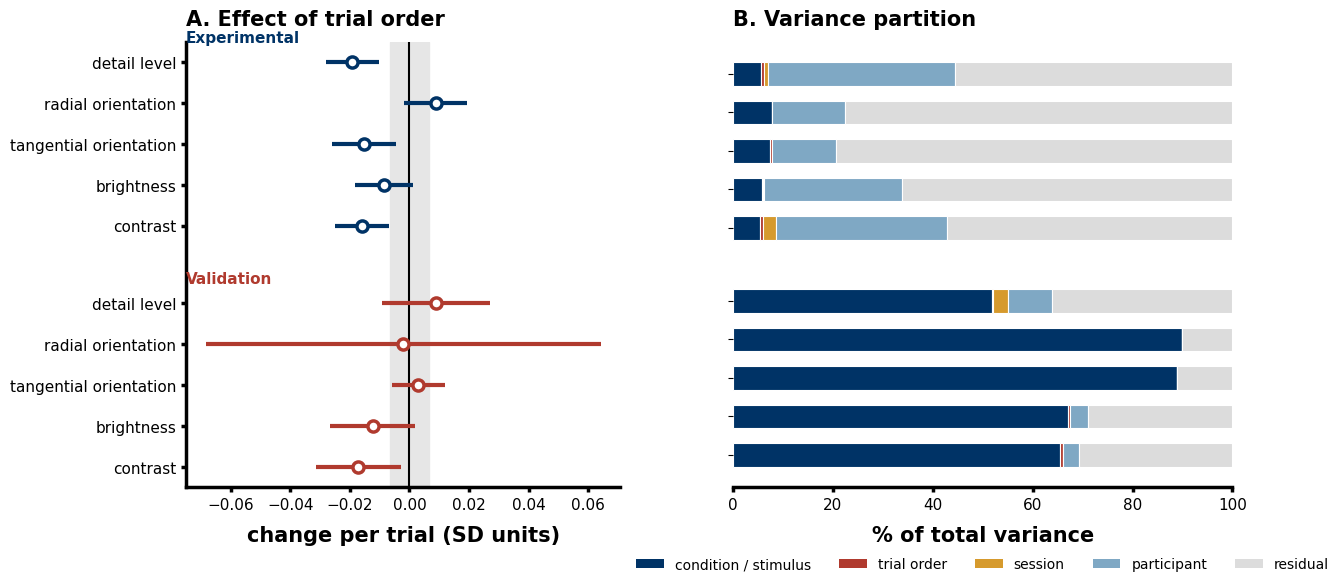

saved: C:\Users\trevo\research\vizex_replication\020_visualizations\figure_S5.4_session_trial_order.png


In [20]:
## Figure S5.4

order = [(fam, name) for fam in ["Experimental", "Validation"] for name in FEATURES.values()]
plot_df = results.set_index(["Family", "Feature"]).loc[order].reset_index()

n = len(plot_df)
ypos = np.arange(n)[::-1].astype(float)
ypos[plot_df["Family"] == "Validation"] -= 0.9

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.0), gridspec_kw={"width_ratios": [1, 1.15]})

# ---------------- Panel A: forest plot ----------------
ax = axes[0]
band = 0.1 / TRIAL_SPAN
ax.axvspan(-band, band, color="0.90", zorder=0)
ax.axvline(0, color="black", lw=1.5, zorder=1)
for i, row in plot_df.iterrows():
    colour = DEFAULT_COLOR if row["Family"] == "Experimental" else PALETTE["trial"]
    if np.isfinite(row["se_trial"]):
        ax.plot([row["ci_lo"], row["ci_hi"]], [ypos[i]] * 2, color=colour, lw=3,
                solid_capstyle="butt", zorder=2)
    ax.plot([row["b_trial"]], [ypos[i]], "o", ms=8, color=colour,
            mfc="white", mew=2.5, zorder=3)

ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["Feature"], fontsize=FONT_SIZE_TICKS)
ax.set_xlabel("change per trial (SD units)", fontsize=FONT_SIZE_MAIN, fontweight="bold", labelpad=10)
ax.set_title("A. Effect of trial order", fontsize=FONT_SIZE_MAIN, fontweight="bold", loc="left", pad=12)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["left", "bottom"]:
    ax.spines[s].set_linewidth(LINE_WEIGHT_AXIS)
ax.tick_params(axis="both", width=LINE_WEIGHT_AXIS, labelsize=FONT_SIZE_TICKS)

x_lab = ax.get_xlim()[0]
for fam, colour in [("Experimental", DEFAULT_COLOR), ("Validation", PALETTE["trial"])]:
    ys = ypos[(plot_df["Family"] == fam).values]
    ax.text(x_lab, ys.max() + 0.6, fam, fontsize=FONT_SIZE_TICKS,
            fontweight="bold", color=colour, ha="left", va="center")

# ---------------- Panel B: variance partition ----------------
ax = axes[1]
segments = [("pct_main", "main", "condition / stimulus"), ("pct_trial", "trial", "trial order"),
            ("pct_session", "session", "session"), ("pct_participant", "participant", "participant"),
            ("pct_resid", "residual", "residual")]
left = np.zeros(n)
for col, key, _ in segments:
    ax.barh(ypos, plot_df[col].values, left=left, height=0.62,
            color=PALETTE[key], edgecolor="white", linewidth=0.8)
    left += plot_df[col].values

ax.set_yticks(ypos)
ax.set_yticklabels([])
ax.set_xlim(0, 100)
ax.set_xlabel("% of total variance", fontsize=FONT_SIZE_MAIN, fontweight="bold", labelpad=10)
ax.set_title("B. Variance partition", fontsize=FONT_SIZE_MAIN, fontweight="bold", loc="left", pad=12)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_linewidth(LINE_WEIGHT_AXIS)
ax.tick_params(axis="x", width=LINE_WEIGHT_AXIS, labelsize=FONT_SIZE_TICKS)
ax.legend(handles=[Patch(facecolor=PALETTE[k], label=lab) for _, k, lab in segments],
          loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=5, frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(viz_path, FIGURE_S54_STEM + ".png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(viz_path, FIGURE_S54_STEM + ".pdf"), bbox_inches="tight")
plt.show()
print(f"saved: {os.path.join(viz_path, FIGURE_S54_STEM + '.png')}")

## Step 9 — does recreation accuracy decline across the session?

The validation trials support a question the experimental trials cannot: participants saw a real
image, so their **error** is measurable. For each trial we take

```
error = (recreation feature - stimulus feature) / SD(recreation feature)
```

The same linear transform is applied to both terms, so the difference is expressed in standard
deviations of the recreated feature and is comparable across features. Absolute error is the
accuracy measure; signed error is checked separately, because a systematic drift toward (say)
sparser drawings would show up in the signed measure while leaving absolute error unchanged.

Two things are controlled. **Difficulty** enters as the target image's own detail level: more
detailed images are harder to reproduce, and the category shown at each position was fixed by
session. **Target level** enters as the target's own value on the feature being modelled, since
images far from the middle of the scale have more room for error in one direction. For detail
level these two coincide and only one is used.

Session is retained in the random structure but not tested again, having been assessed in
Table S5.2. Holm correction is applied across the six tests (five features plus the composite).

In [21]:
## build the accuracy measures

for f in FEATURES:
    val["err_" + f] = val["z_" + f] - val["zc_stim_" + f]      # signed, in recreation SD units
    val["abs_" + f] = val["err_" + f].abs()

val["abs_mean"] = val[["abs_" + f for f in FEATURES]].mean(axis=1)
val["err_mean"] = val[["err_" + f for f in FEATURES]].mean(axis=1)
val["difficulty"] = val["zs_detail"]                            # target detail as difficulty proxy

summary = pd.DataFrame({
    "feature": [FEATURES[f] for f in FEATURES],
    "mean signed error": [val["err_" + f].mean() for f in FEATURES],
    "mean absolute error": [val["abs_" + f].mean() for f in FEATURES],
    "SD of absolute error": [val["abs_" + f].std(ddof=1) for f in FEATURES],
})
display(summary.round(3))
print(f"composite (mean across features): mean absolute error = {val['abs_mean'].mean():.3f} SD")
print("\nA mean signed error near zero indicates no systematic bias; the absolute error is the")
print("typical size of a recreation's departure from its target, in SD of the recreated feature.")

,feature,mean signed error,mean absolute error,SD of absolute error
0,detail level,-1.219,1.245,1.169
1,radial orientation,-0.194,0.310,0.373
2,tangential orientation,0.047,0.254,0.267
3,brightness,0.048,0.422,0.391
4,contrast,-0.050,0.445,0.409


composite (mean across features): mean absolute error = 0.535 SD

A mean signed error near zero indicates no systematic bias; the absolute error is the
typical size of a recreation's departure from its target, in SD of the recreated feature.


In [22]:
## accuracy models: absolute error ~ trial order + difficulty + target level

def accuracy_formula(outcome, feat=None):
    terms = ["trial_c", "difficulty"]
    if feat is not None and feat != "detail":
        terms.append(f"zs_{feat}")
    return f"{outcome} ~ " + " + ".join(terms)


acc_rows = []
targets = [("abs_" + f, FEATURES[f], f) for f in FEATURES] + [("abs_mean", "composite (all five)", None)]

for outcome, name, feat in targets:
    formula = accuracy_formula(outcome, feat)
    model, res = fit_best(formula, val, "session", VC_FORMULA)

    target_cols = [c for c in model.exog_names if c.startswith(("difficulty", "zs_"))]
    v_target = fixed_effect_variance(model, res, target_cols)
    v_trial = fixed_effect_variance(model, res, ["trial_c"])
    v_session = float(np.asarray(res.cov_re)[0, 0])
    v_participant = float(np.atleast_1d(res.vcomp)[0])
    v_resid = float(res.scale)
    total = v_target + v_trial + v_session + v_participant + v_resid

    _, res_notrial = fit_best(drop_term(formula, "trial_c"), val, "session", VC_FORMULA)
    lrt = max(2 * (res.llf - res_notrial.llf), 0.0)
    p = chi2.sf(lrt, 1)

    b = float(res.fe_params["trial_c"])
    se = safe_se(res, "trial_c")

    # signed-error counterpart, as a bias check
    _, res_signed = fit_best(accuracy_formula(outcome.replace("abs_", "err_"), feat),
                             val, "session", VC_FORMULA)
    b_signed = float(res_signed.fe_params["trial_c"])

    acc_rows.append({
        "Feature": name, "b_trial": b, "se_trial": se,
        "ci_lo": b - 1.96 * se, "ci_hi": b + 1.96 * se,
        "lrt_trial": lrt, "p_trial": p, "delta_total": b * TRIAL_SPAN,
        "b_signed": b_signed, "mean_abs": val[outcome].mean(),
        "pct_target": 100 * v_target / total, "pct_trial": 100 * v_trial / total,
        "pct_session": 100 * v_session / total,
        "pct_participant": 100 * v_participant / total, "pct_resid": 100 * v_resid / total,
        "is_composite": feat is None,
    })
    print(f"  fitted [Accuracy] {name}")

res_acc = pd.DataFrame(acc_rows)
_, p_holm, _, _ = multipletests(res_acc["p_trial"], alpha=0.05, method="holm")
res_acc["p_trial_holm"] = p_holm
display(res_acc[["Feature", "b_trial", "se_trial", "lrt_trial", "p_trial", "p_trial_holm",
                 "delta_total", "b_signed"]].round(4))

  fitted [Accuracy] detail level
  fitted [Accuracy] radial orientation
  fitted [Accuracy] tangential orientation
  fitted [Accuracy] brightness
  fitted [Accuracy] contrast
  fitted [Accuracy] composite (all five)


,Feature,b_trial,se_trial,lrt_trial,p_trial,p_trial_holm,delta_total,b_signed
0,detail level,-0.0120,0.0088,1.8420,0.1747,0.8736,-0.1794,0.0089
1,radial orientation,0.0015,0.0037,0.1621,0.6872,1.0000,0.0220,-0.0041
2,tangential orientation,0.0033,0.0034,0.9626,0.3265,1.0000,0.0492,0.0023
3,brightness,0.0076,0.0049,2.4087,0.1207,0.7240,0.1147,-0.0135
4,contrast,0.0045,0.0049,0.8621,0.3532,1.0000,0.0679,-0.0225
5,composite (all five),0.0019,0.0027,0.5234,0.4694,1.0000,0.0289,-0.0067


In [23]:
## build, print and save Table S5.3

table_s53 = pd.DataFrame({
    "Feature": res_acc["Feature"],
    "mean abs. error (SD)": res_acc["mean_abs"].round(3),
    "b per trial (SE)": [f"{b:+.4f} (-)" if not np.isfinite(se) else f"{b:+.4f} ({se:.4f})"
                         for b, se in zip(res_acc["b_trial"], res_acc["se_trial"])],
    "95% CI": ["-" if not np.isfinite(se) else f"[{lo:+.4f}, {hi:+.4f}]"
               for lo, hi, se in zip(res_acc["ci_lo"], res_acc["ci_hi"], res_acc["se_trial"])],
    "chi2(1)": res_acc["lrt_trial"].round(2),
    "p": [fmt_p(p) for p in res_acc["p_trial_holm"]],
    "drift across expt (SD)": res_acc["delta_total"].round(3),
    "signed b per trial": res_acc["b_signed"].round(4),
    "% target": res_acc["pct_target"].round(1),
    "% trial order": res_acc["pct_trial"].round(2),
    "% session": res_acc["pct_session"].round(1),
    "% participant": res_acc["pct_participant"].round(1),
    "% residual": res_acc["pct_resid"].round(1),
})

print("=" * 165)
print("TABLE S5.3. Effect of trial order on recreation accuracy (validation trials)")
print("=" * 165)
print(f"\nn = {len(val)} drawings, {val['participant_code'].nunique()} participants, "
      f"{val['session'].nunique()} sessions, {val['condition_code'].nunique()} target images")
print(table_s53.to_string(index=False))
print("\nNote. Absolute error is |recreation - stimulus| in standard deviations of the recreated")
print("feature. b is the change in absolute error per trial; drift is the implied change across")
print(f"the {TRIAL_SPAN + 1}-trial sequence. The signed coefficient is from the same model fitted to signed")
print("error, and indicates directional bias rather than accuracy. All models control for target")
print("difficulty and target level and include nested session and participant random intercepts.")
print("Tests are likelihood-ratio tests, Holm-Bonferroni corrected across the six rows.")

save_table(table_s53, TABLE_S53_STEM,
           "Effect of trial order on recreation accuracy in the validation trials.", "tab:S5.3")
res_acc.to_csv(os.path.join(tables_path, TABLE_S53_STEM + "_raw.csv"), index=False)

TABLE S5.3. Effect of trial order on recreation accuracy (validation trials)

n = 295 drawings, 99 participants, 17 sessions, 45 target images
               Feature  mean abs. error (SD) b per trial (SE)             95% CI  chi2(1)     p  drift across expt (SD)  signed b per trial  % target  % trial order  % session  % participant  % residual
          detail level                 1.245 -0.0120 (0.0088) [-0.0292, +0.0053]     1.84  .874                  -0.179              0.0089      67.5           0.21        2.3            6.3        23.7
    radial orientation                 0.310 +0.0015 (0.0037) [-0.0057, +0.0087]     0.16 1.000                   0.022             -0.0041      43.9           0.03        0.0            0.0        56.0
tangential orientation                 0.254 +0.0033 (0.0034) [-0.0033, +0.0099]     0.96 1.000                   0.049              0.0023       8.4           0.31        0.0            0.0        91.3
            brightness                 0.422 

## Step 10 — Figure S5.5

Panel A plots composite absolute error against position in the trial sequence, with the breaks
after the 5th and 10th trials marked. Panel B shows the per-feature trial-order slopes on absolute
error.

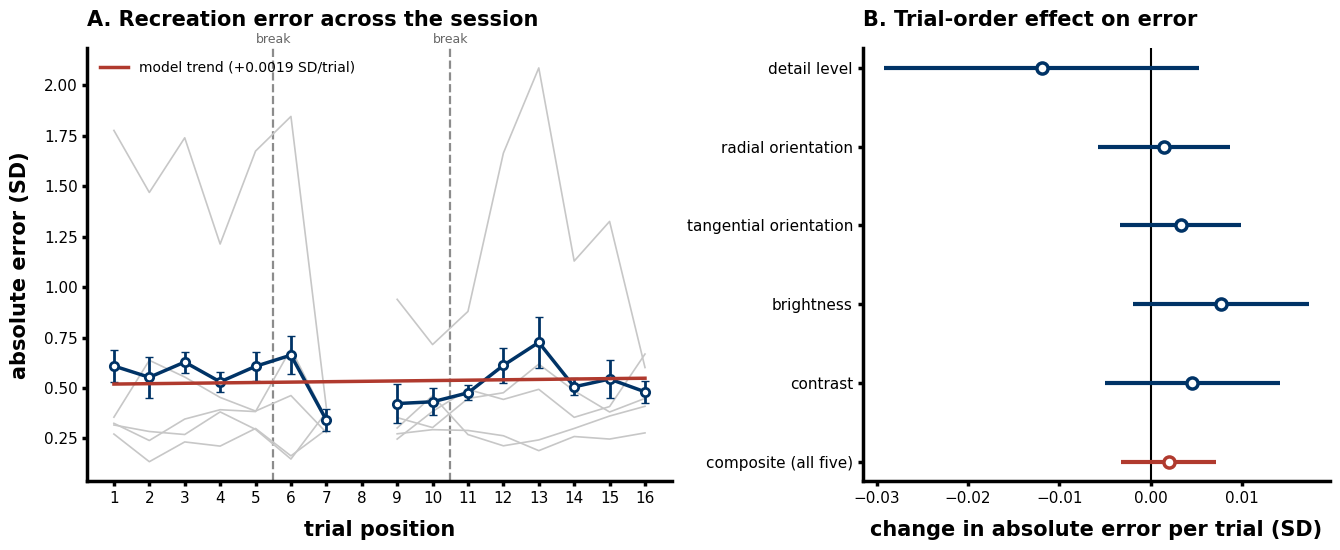

saved: C:\Users\trevo\research\vizex_replication\020_visualizations\figure_S5.5_recreation_accuracy.png
validation trials per position: 6-44


In [24]:
## Figure S5.5

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6), gridspec_kw={"width_ratios": [1.25, 1]})

# ---------------- Panel A: accuracy across the sequence ----------------
ax = axes[0]
positions = np.arange(TRIAL_FIRST, TRIAL_LAST + 1)

for b in BREAKS_AFTER:
    ax.axvline(b + 0.5, color="0.55", lw=1.6, ls="--", zorder=1)
    ax.text(b + 0.5, 1.005, "break", transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=9, color="0.4")

# light per-feature lines
for f in FEATURES:
    g = val.groupby("trial_pos")["abs_" + f].mean().reindex(positions)
    ax.plot(positions, g.values, color="0.78", lw=1.2, zorder=2)

# composite with SEM
g = val.groupby("trial_pos")["abs_mean"]
mean_by_pos = g.mean().reindex(positions)
sem_by_pos = g.sem().reindex(positions)
n_by_pos = g.size().reindex(positions)
ax.errorbar(positions, mean_by_pos.values, yerr=sem_by_pos.values, fmt="none",
            ecolor=DEFAULT_COLOR, elinewidth=2, capsize=3, zorder=3)
ax.plot(positions, mean_by_pos.values, "-o", color=DEFAULT_COLOR, lw=2.5, ms=6,
        mfc="white", mew=2, zorder=4)

# model-implied linear trend (composite, difficulty held at its mean)
comp = res_acc[res_acc["is_composite"]].iloc[0]
_, res_comp = fit_best(accuracy_formula("abs_mean"), val, "session", VC_FORMULA)
trend = float(res_comp.fe_params["Intercept"]) + comp["b_trial"] * (positions - TRIAL_CENTER)
ax.plot(positions, trend, color=PALETTE["trial"], lw=2.5, ls="-", zorder=5,
        label=f"model trend ({comp['b_trial']:+.4f} SD/trial)")

ax.set_xticks(positions)
ax.set_xlabel("trial position", fontsize=FONT_SIZE_MAIN, fontweight="bold", labelpad=10)
ax.set_ylabel("absolute error (SD)", fontsize=FONT_SIZE_MAIN, fontweight="bold", labelpad=10)
ax.set_title("A. Recreation error across the session", fontsize=FONT_SIZE_MAIN,
             fontweight="bold", loc="left", pad=16)
ax.legend(frameon=False, fontsize=10, loc="upper left")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["left", "bottom"]:
    ax.spines[s].set_linewidth(LINE_WEIGHT_AXIS)
ax.tick_params(axis="both", width=LINE_WEIGHT_AXIS, labelsize=FONT_SIZE_TICKS)

# ---------------- Panel B: per-feature slopes ----------------
ax = axes[1]
pf = res_acc.iloc[::-1].reset_index(drop=True)
yp = np.arange(len(pf), dtype=float)
ax.axvline(0, color="black", lw=1.5, zorder=1)
for i, row in pf.iterrows():
    colour = DEFAULT_COLOR if not row["is_composite"] else PALETTE["trial"]
    if np.isfinite(row["se_trial"]):
        ax.plot([row["ci_lo"], row["ci_hi"]], [yp[i]] * 2, color=colour, lw=3,
                solid_capstyle="butt", zorder=2)
    ax.plot([row["b_trial"]], [yp[i]], "o", ms=8, color=colour, mfc="white", mew=2.5, zorder=3)

ax.set_yticks(yp)
ax.set_yticklabels(pf["Feature"], fontsize=FONT_SIZE_TICKS)
ax.set_xlabel("change in absolute error per trial (SD)", fontsize=FONT_SIZE_MAIN,
              fontweight="bold", labelpad=10)
ax.set_title("B. Trial-order effect on error", fontsize=FONT_SIZE_MAIN,
             fontweight="bold", loc="left", pad=16)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["left", "bottom"]:
    ax.spines[s].set_linewidth(LINE_WEIGHT_AXIS)
ax.tick_params(axis="both", width=LINE_WEIGHT_AXIS, labelsize=FONT_SIZE_TICKS)

plt.tight_layout()
plt.savefig(os.path.join(viz_path, FIGURE_S55_STEM + ".png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(viz_path, FIGURE_S55_STEM + ".pdf"), bbox_inches="tight")
plt.show()
print(f"saved: {os.path.join(viz_path, FIGURE_S55_STEM + '.png')}")
print(f"validation trials per position: {int(n_by_pos.min())}-{int(n_by_pos.max())}")

## Step 11 — sentences you can paste into the supplement

The cell below writes the result up with the numbers filled in, choosing wording appropriate to
whichever outcome the data gave. Check it, then edit for voice.

In [25]:
## auto-generated reporting text

def describe(res_df, label, main_word):
    sig_t = res_df[res_df["p_trial_holm"] < .05]
    sig_s = res_df[res_df["p_session_holm"] < .05]
    biggest = res_df.loc[res_df["delta_total"].abs().idxmax()]

    out = [f"[{label}]"]
    if len(sig_t) == 0:
        out.append(
            f"No feature showed a significant linear effect of trial order (all Holm-corrected "
            f"p > .05). The largest estimated drift was for {biggest['Feature']} "
            f"(b = {biggest['b_trial']:+.4f} SD per trial, {fmt_p_apa(biggest['p_trial_holm'])}), "
            f"equivalent to {biggest['delta_total']:+.3f} SD across the {TRIAL_SPAN + 1}-trial sequence.")
    else:
        names = ", ".join(sig_t["Feature"])
        out.append(
            f"{len(sig_t)} of 5 features showed a significant linear effect of trial order "
            f"({names}). Effects were small: the largest was for {biggest['Feature']} "
            f"(b = {biggest['b_trial']:+.4f} SD per trial, chi2(1) = {biggest['lrt_trial']:.2f}, "
            f"{fmt_p_apa(biggest['p_trial_holm'])}), a change of {biggest['delta_total']:+.3f} SD "
            f"across the {TRIAL_SPAN + 1}-trial sequence.")
    out.append(
        f"Trial order accounted for {res_df['pct_trial'].min():.2f}-{res_df['pct_trial'].max():.2f}% "
        f"of total variance, against {res_df['pct_main'].min():.1f}-{res_df['pct_main'].max():.1f}% "
        f"for {main_word} and {res_df['pct_participant'].min():.1f}-"
        f"{res_df['pct_participant'].max():.1f}% for stable participant differences.")
    if len(sig_s) == 0:
        out.append(
            f"Adding a session-level random intercept did not improve model fit for any feature "
            f"(all Holm-corrected p > .05; session variance "
            f"{res_df['pct_session'].min():.1f}-{res_df['pct_session'].max():.1f}% of the total).")
    else:
        names = ", ".join(sig_s["Feature"])
        out.append(
            f"Session-level clustering was detected for {len(sig_s)} of 5 features ({names}), "
            f"accounting for {res_df['pct_session'].min():.1f}-{res_df['pct_session'].max():.1f}% "
            f"of total variance.")
    return " ".join(out)


print(describe(res_exp, "Experimental trials", "stroboscopic frequency"))
print()
print(describe(res_val, "Validation trials", "the stimulus feature value"))
print()

comp = res_acc[res_acc["is_composite"]].iloc[0]
sig_a = res_acc[(res_acc["p_trial_holm"] < .05) & (~res_acc["is_composite"])]
acc = [f"[Recreation accuracy] Mean absolute error was {comp['mean_abs']:.3f} SD of the recreated "
       f"feature."]
if len(sig_a) == 0:
    acc.append(
        f"Absolute error did not change reliably across the trial sequence for any feature or for "
        f"the composite measure (all Holm-corrected p > .05; composite b = {comp['b_trial']:+.4f} SD "
        f"per trial, {fmt_p_apa(comp['p_trial_holm'])}, a change of {comp['delta_total']:+.3f} SD "
        f"across the experiment). Accuracy was therefore stable from the first trial to the last.")
else:
    acc.append(
        f"Absolute error changed reliably across the sequence for {len(sig_a)} of 5 features "
        f"({', '.join(sig_a['Feature'])}); the composite measure "
        f"{'also changed' if comp['p_trial_holm'] < .05 else 'did not change'} "
        f"(b = {comp['b_trial']:+.4f} SD per trial, {fmt_p_apa(comp['p_trial_holm'])}, "
        f"{comp['delta_total']:+.3f} SD across the experiment).")
acc.append(
    f"Trial order accounted for {res_acc['pct_trial'].min():.2f}-{res_acc['pct_trial'].max():.2f}% "
    f"of variance in error, against {res_acc['pct_target'].min():.1f}-"
    f"{res_acc['pct_target'].max():.1f}% for target difficulty and level.")
print(" ".join(acc))
print()
print(f"[Robustness] Accounting for session and trial order changed the frequency coefficients of "
      f"the main analysis by at most {stability['max |change| (SD)'].max():.3f} SD "
      f"(minimum correlation between coefficient sets r = {stability['r(base, full)'].min():.3f}).")

[Experimental trials] 3 of 5 features showed a significant linear effect of trial order (detail level, tangential orientation, contrast). Effects were small: the largest was for detail level (b = -0.0192 SD per trial, chi2(1) = 17.36, p < .001), a change of -0.287 SD across the 16-trial sequence. Trial order accounted for 0.15-0.78% of total variance, against 5.5-7.7% for stroboscopic frequency and 12.8-37.4% for stable participant differences. Adding a session-level random intercept did not improve model fit for any feature (all Holm-corrected p > .05; session variance 0.0-2.6% of the total).

[Validation trials] No feature showed a significant linear effect of trial order (all Holm-corrected p > .05). The largest estimated drift was for contrast (b = -0.0171 SD per trial, p = .207), equivalent to -0.257 SD across the 16-trial sequence. Trial order accounted for 0.01-0.61% of total variance, against 51.9-89.9% for the stimulus feature value and 0.0-8.8% for stable participant differen

## Optional — sensitivity checks

Three questions a careful reader might raise. None belongs in the supplement unless it changes the
conclusion; run them, note the answer in a sentence, and move on.

1. **Is the drift linear?** A quadratic term tests for effects that accelerate late in the session.
2. **Does fatigue reset at the breaks?** Position since the last break is an alternative account of
   the same data. The two models are not nested, so they are compared by AIC.
3. **Does the order effect differ between sessions?** A random slope for trial position by session.
   This is demanding on ~17 sessions and may not converge; a failure to converge is uninformative,
   not evidence of anything.

In [26]:
## sensitivity 1: is the drift linear?

exp["trial_c2"] = exp["trial_c"] ** 2
rows = []
for feat, name in FEATURES.items():
    _, r_lin = fit_best(f"z_{feat} ~ C(condition_hz) + trial_c", exp, "session", VC_FORMULA)
    _, r_quad = fit_best(f"z_{feat} ~ C(condition_hz) + trial_c + trial_c2", exp, "session", VC_FORMULA)
    lrt = max(2 * (r_quad.llf - r_lin.llf), 0.0)
    rows.append({"Feature": name, "chi2(1)": lrt, "p": chi2.sf(lrt, 1)})

quad = pd.DataFrame(rows)
quad["p (Holm)"] = multipletests(quad["p"], alpha=0.05, method="holm")[1]
display(quad.round(4))
print("A non-significant chi2 means a straight line describes the drift adequately.")

,Feature,chi2(1),p,p (Holm)
0,detail level,5.9401,0.0148,0.0740
1,radial orientation,1.2859,0.2568,0.7704
2,tangential orientation,0.1040,0.7471,1.0000
3,brightness,3.5929,0.0580,0.2321
4,contrast,0.1731,0.6774,1.0000


A non-significant chi2 means a straight line describes the drift adequately.


In [27]:
## sensitivity 2: linear drift vs. position since the last break

exp["pos_break_c"] = exp["pos_since_break"] - exp["pos_since_break"].mean()
rows = []
for feat, name in FEATURES.items():
    _, r_lin = fit_best(f"z_{feat} ~ C(condition_hz) + trial_c", exp, "session", VC_FORMULA)
    _, r_brk = fit_best(f"z_{feat} ~ C(condition_hz) + pos_break_c", exp, "session", VC_FORMULA)
    rows.append({"Feature": name, "AIC linear": r_lin.aic, "AIC since-break": r_brk.aic,
                 "better": "linear" if r_lin.aic < r_brk.aic else "since-break"})
display(pd.DataFrame(rows).round(1))
print(f"Breaks were given after trials {BREAKS_AFTER}. A difference of less than about 2 AIC")
print("points means the two accounts are indistinguishable in these data.")

,Feature,AIC linear,AIC since-break,better
0,detail level,3133.5,3145.0,linear
1,radial orientation,3454.9,3456.9,linear
2,tangential orientation,3474.8,3478.1,linear
3,brightness,3313.7,3316.5,linear
4,contrast,3159.6,3168.6,linear


Breaks were given after trials (5, 10). A difference of less than about 2 AIC
points means the two accounts are indistinguishable in these data.


In [28]:
## sensitivity 3: does the trial-order slope vary by session?

for feat, name in FEATURES.items():
    try:
        _, r_fixed = fit_best(f"z_{feat} ~ C(condition_hz) + trial_c", exp, "session", VC_FORMULA)
        _, r_slope = fit_best(f"z_{feat} ~ C(condition_hz) + trial_c", exp, "session",
                              VC_FORMULA, re_formula="1 + trial_c")
        lrt = max(2 * (r_slope.llf - r_fixed.llf), 0.0)
        print(f"{name:<24} chi2(2) = {lrt:6.2f}, {fmt_p_apa(chi2.sf(lrt, 2))}")
    except Exception as err:
        print(f"{name:<24} did not converge ({type(err).__name__}) - not interpretable")

detail level             chi2(2) =  12.26, p = .002
radial orientation       chi2(2) =   3.09, p = .214
tangential orientation   chi2(2) =   0.40, p = .820
brightness               chi2(2) =   1.13, p = .569
contrast                 chi2(2) =   2.22, p = .329
